# Experiment 4: Binary Classification using Linear and Kernel-Based Models

Name: Kushaal Shyam Potta

Reg No.: 3122235001071

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


### **1) Loading the dataset**

In [2]:
df=pd.read_csv('dataset/spambase_csv.csv')
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


### **2. Preprocessing the data:**
• Handle missing values

• Standardize features

In [3]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [4]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

(4601, 58)

In [5]:
df=df.drop_duplicates()
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [6]:
df=df.drop_duplicates()
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


### **3) Performing Exploratory Data Analysis (EDA)**

**Histogram Distribution of Class Column:**

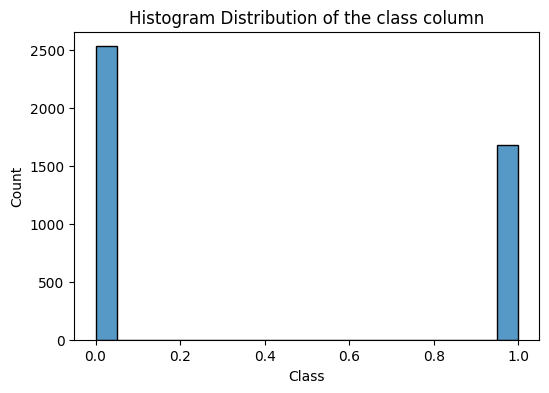

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(x=df["class"],bins=20)
plt.title("Histogram Distribution of the class column")
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

**Class Distribution (spam vs ham):**


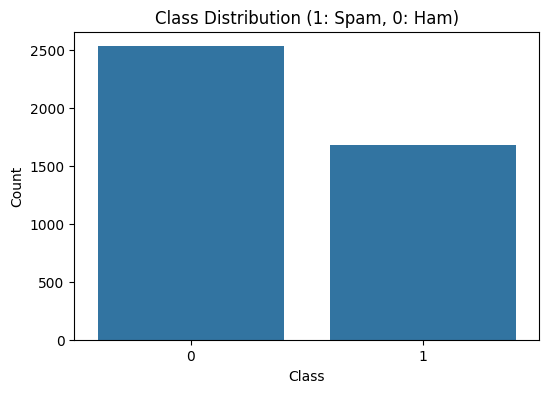

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["class"])
plt.title("Class Distribution (1: Spam, 0: Ham)")
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

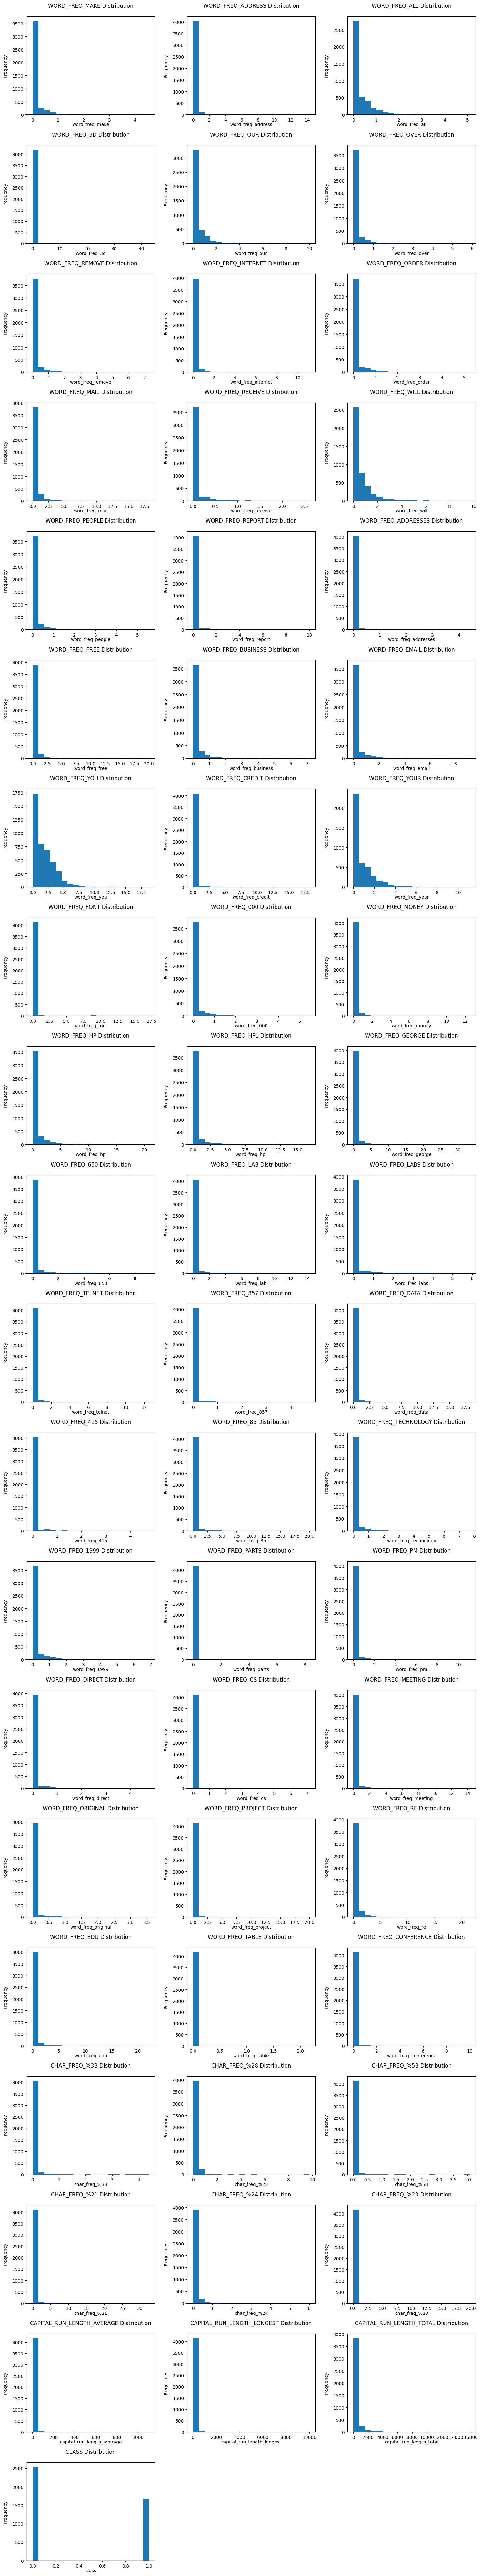

In [9]:
#Histogram plots of all features
bxwidth=1
rows=math.ceil(len(df.columns)/3)
fig,axes=plt.subplots(rows,3,figsize=(15,4*rows))
axes=axes.flatten()
columns=df.columns
for i,(ax,col) in enumerate(zip(axes,columns)):
  ax.hist(df[col],bins=20)
  ax.set_title(f"{col.upper()} Distribution",pad=20)
  ax.set_xlabel(col,labelpad=0)
  ax.set_ylabel("Frequency",labelpad=10)
for spine in ax.spines.values():
  spine.set_linewidth(bxwidth)
for j in range(i+1,len(axes)):
  fig.delaxes(axes[j])
plt.subplots_adjust(hspace=1.5,wspace=1.3)
plt.tight_layout()
plt.show()

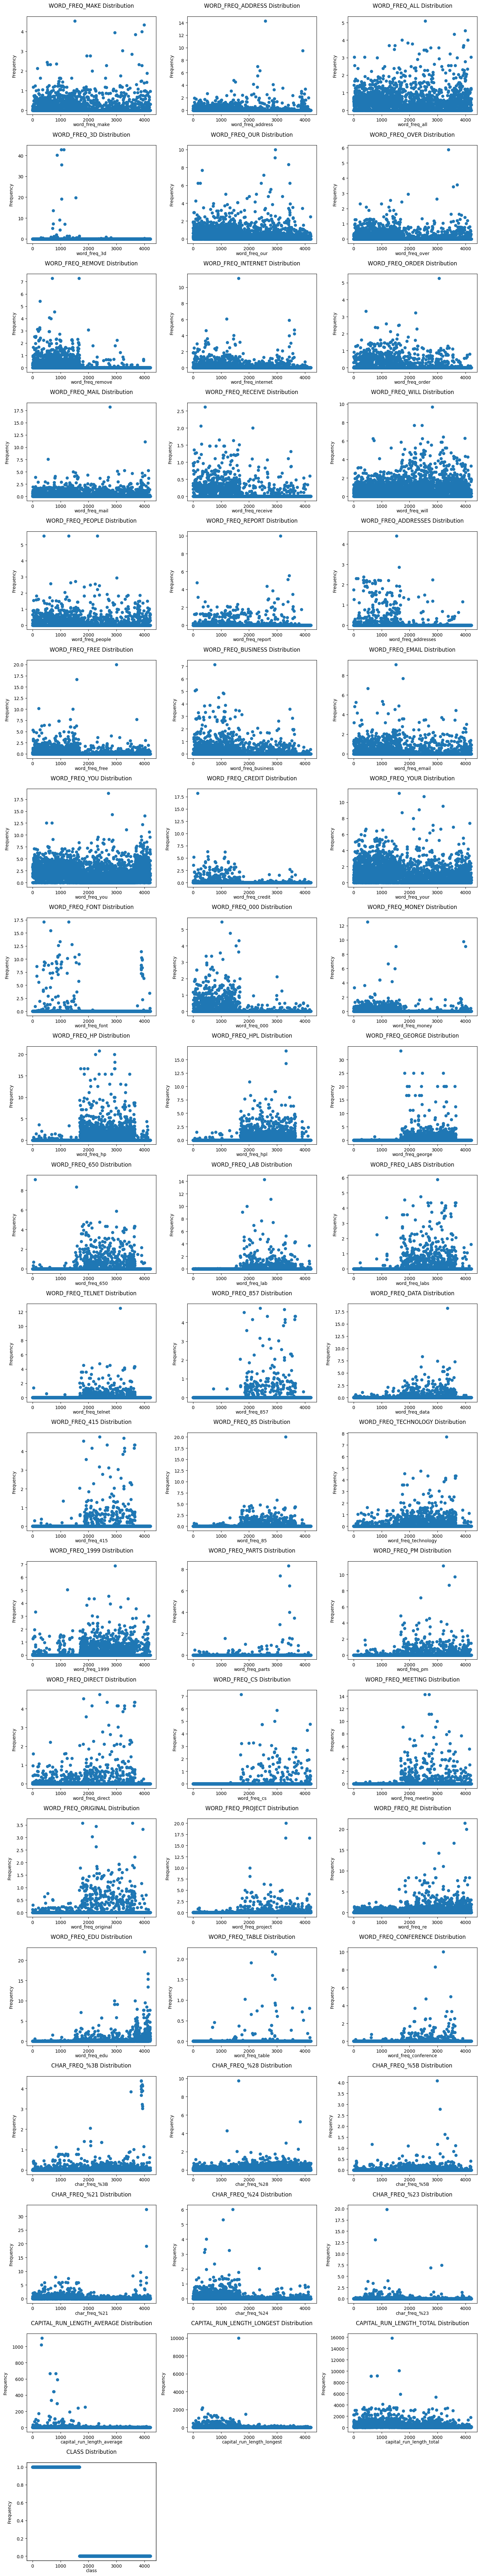

In [12]:
#Scatter plots of all features
bxwidth=1
rows=math.ceil(len(df.columns)/3)
fig,axes=plt.subplots(rows,3,figsize=(15,4*rows))
axes=axes.flatten()
columns=df.columns
for i,(ax,col) in enumerate(zip(axes,columns)):
  ax.scatter(range(len(df)),df[col])
  ax.set_title(f"{col.upper()} Distribution",pad=20)
  ax.set_xlabel(col,labelpad=0)
  ax.set_ylabel("Frequency",labelpad=10)
for spine in ax.spines.values():
  spine.set_linewidth(bxwidth)
for j in range(i+1,len(axes)):
  fig.delaxes(axes[j])
plt.subplots_adjust(hspace=1.5,wspace=1.3)
plt.tight_layout()
plt.show()

### **4) Split the dataset into training and testing sets.**

In [10]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print(f"Training set size:{X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

Training set size:(3368, 57)
Test set size: (842, 57)


### **5) Train baseline Logistic Regression.**

In [19]:
def evaluate_model(model, X_test, y_test, training_time):
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    print(f"Training Time: {training_time:.4f}s")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1, "Time":training_time}

# Logistic Regression
start_time=time.time()
lr_baseline=LogisticRegression(max_iter=1000)
lr_baseline.fit(X_train_scaled,y_train)
end_time =time.time()
lr_metrics=evaluate_model(lr_baseline,X_test_scaled,y_test,end_time-start_time)


Training Time: 0.0079s
Accuracy: 0.9347
Precision: 0.9297
Recall: 0.9048
F1 Score: 0.9170


### **6) Tune Logistic Regression hyperparameters.**

In [20]:
lr_param_grid={
    'C':[0.01,0.1,1,10,100],
    'penalty':['l1','l2'],
    'solver':['liblinear','saga']
}

grid_lr=GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),lr_param_grid,cv=5,n_jobs=-1)

start_time=time.time()
grid_lr.fit(X_train_scaled,y_train)
end_time=time.time()

print(f"Best Hyperparameters: {grid_lr.best_params_}")
print(f"Best CV Accuracy: {grid_lr.best_score_:.4f}")
best_lr_model=grid_lr.best_estimator_

/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

Best Hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.9243


### **7) Train SVM with different kernels.**

In [22]:
kernels=['linear','rbf','poly','sigmoid']
svm_results=[]

for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel")
    svm_model=SVC(kernel=kernel,random_state=42)
    start_time=time.time()
    svm_model.fit(X_train_scaled,y_train)
    end_time=time.time()

    print("Evaluation on Test Set:")
    metrics=evaluate_model(svm_model,X_test_scaled,y_test,end_time-start_time)
    metrics['Kernel']=kernel
    svm_results.append(metrics)


svm_results_df = pd.DataFrame(svm_results)

svm_results_df


Training SVM with linear kernel
Evaluation on Test Set:
Training Time: 0.2153s
Accuracy: 0.9359
Precision: 0.9273
Recall: 0.9107
F1 Score: 0.9189

Training SVM with rbf kernel
Evaluation on Test Set:
Training Time: 0.1114s
Accuracy: 0.9323
Precision: 0.9319
Recall: 0.8958
F1 Score: 0.9135

Training SVM with poly kernel
Evaluation on Test Set:
Training Time: 0.2084s
Accuracy: 0.7660
Precision: 0.9484
Recall: 0.4375
F1 Score: 0.5988

Training SVM with sigmoid kernel
Evaluation on Test Set:
Training Time: 0.1259s
Accuracy: 0.8967
Precision: 0.8879
Recall: 0.8482
F1 Score: 0.8676


,Accuracy,Precision,Recall,F1 Score,Time,Kernel
0,0.935867,0.927273,0.910714,0.918919,0.215317,linear
1,0.932304,0.931889,0.895833,0.913505,0.111367,rbf
2,0.766033,0.948387,0.437500,0.598778,0.208393,poly
3,0.896675,0.887850,0.848214,0.867580,0.125879,sigmoid


### **8) Tune SVM hyperparameters.**

In [27]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf'] 
}

grid_svm = GridSearchCV(SVC(random_state=42), svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)

start_time = time.time()
grid_svm.fit(X_train_scaled, y_train)
end_time = time.time()

print(f"Best SVM Parameters: {grid_svm.best_params_}")
best_svm_model = grid_svm.best_estimator_

Best SVM Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


### Table: Hyperparameter tuning results

In [29]:
tuning_results = [
    {
        "Model": "Logistic Regression",
        "Search Method": "Grid Search",
        "Best Parameters": str(grid_lr.best_params_),
        "Best CV Accuracy": round(grid_lr.best_score_, 4)
    },
    {
        "Model": "SVM",
        "Search Method": "Grid Search",
        "Best Parameters": str(grid_svm.best_params_),
        "Best CV Accuracy": round(grid_svm.best_score_, 4)
    }
]

tuning_df = pd.DataFrame(tuning_results)
tuning_df

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}",0.9243
1,SVM,Grid Search,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9255


### **9) Evaluate models using standard metrics.**


--- Evaluation Metrics for Logistic Regression ---
Accuracy : 0.9371
Precision: 0.9301
Recall   : 0.9107
F1 Score : 0.9203

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       506
           1       0.93      0.91      0.92       336

    accuracy                           0.94       842
   macro avg       0.94      0.93      0.93       842
weighted avg       0.94      0.94      0.94       842



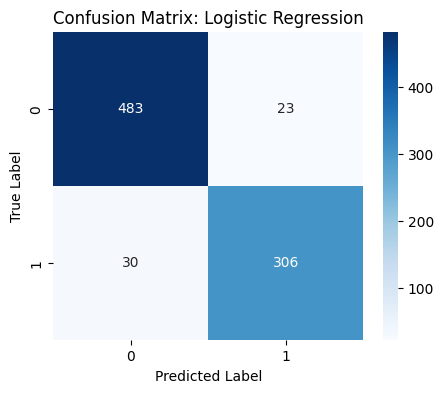


--- Evaluation Metrics for Support Vector Machine ---
Accuracy : 0.9335
Precision: 0.9294
Recall   : 0.9018
F1 Score : 0.9154

Classification Report for Support Vector Machine:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       506
           1       0.93      0.90      0.92       336

    accuracy                           0.93       842
   macro avg       0.93      0.93      0.93       842
weighted avg       0.93      0.93      0.93       842



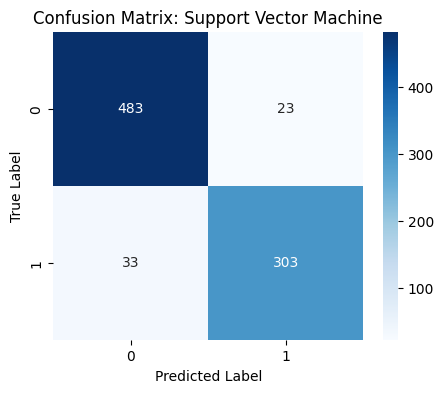

In [30]:

def display_evaluation_metrics(model_name, y_true, y_pred):
    
    print(f"\n--- Evaluation Metrics for {model_name} ---")
    
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred))
    
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


y_pred_lr = best_lr_model.predict(X_test_scaled)
display_evaluation_metrics("Logistic Regression", y_test, y_pred_lr)


y_pred_svm = best_svm_model.predict(X_test_scaled)
display_evaluation_metrics("Support Vector Machine", y_test, y_pred_svm)

### **10) Perform 5-Fold Cross-Validation.**

In [25]:

print("\n--- 5-Fold Cross-Validation Results ---")


lr_cv_scores = cross_val_score(best_lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Logistic Regression CV Scores: {lr_cv_scores}")
print(f"Average LR Accuracy: {lr_cv_scores.mean():.4f}")


svm_cv_scores = cross_val_score(best_svm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"SVM CV Scores: {svm_cv_scores}")
print(f"Average SVM Accuracy: {svm_cv_scores.mean():.4f}")


fold_data = {
    'Fold': [f'Fold {i+1}' for i in range(5)] + ['Average'],
    'Logistic Regression': list(lr_cv_scores) + [lr_cv_scores.mean()],
    'SVM': list(svm_cv_scores) + [svm_cv_scores.mean()]
}

cv_df = pd.DataFrame(fold_data)
print("\nCross-Validation Table:\n", cv_df)


--- 5-Fold Cross-Validation Results ---


/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kushaal/machine-learning-lab/venv_ml/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

Logistic Regression CV Scores: [0.91691395 0.92581602 0.92433234 0.92124814 0.93313522]
Average LR Accuracy: 0.9243
SVM CV Scores: [0.91394659 0.92136499 0.92136499 0.92719168 0.9435364 ]
Average SVM Accuracy: 0.9255

Cross-Validation Table:
       Fold  Logistic Regression       SVM
0   Fold 1             0.916914  0.913947
1   Fold 2             0.925816  0.921365
2   Fold 3             0.924332  0.921365
3   Fold 4             0.921248  0.927192
4   Fold 5             0.933135  0.943536
5  Average             0.924289  0.925481


In [26]:

print("\n--- Final Comparative Analysis ---")
print(f"{'Criterion':<20} | {'Logistic Regression':<20} | {'SVM':<20}")
print("-" * 65)
print(f"{'Accuracy':<20} | {lr_cv_scores.mean():<20.4f} | {svm_cv_scores.mean():<20.4f}")
print(f"{'Model Complexity':<20} | {'Low':<20} | {'High':<20}")
print(f"{'Interpretability':<20} | {'High':<20} | {'Low':<20}")


--- Final Comparative Analysis ---
Criterion            | Logistic Regression  | SVM                 
-----------------------------------------------------------------
Accuracy             | 0.9243               | 0.9255              
Model Complexity     | Low                  | High                
Interpretability     | High                 | Low                 
